The digit: 7


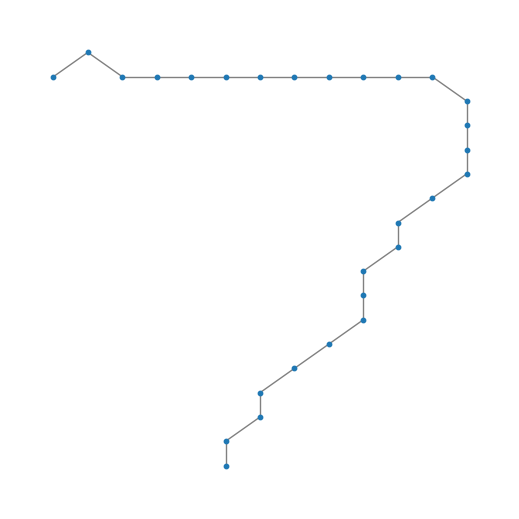

In [3]:
import numpy as np
import networkx as nx
import cv2
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from sklearn.metrics import pairwise_distances
from tensorflow.keras.datasets import mnist

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

def preprocess_image(image):
    """Convert an image to binary and skeletonize it."""
    _, binary = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY)
    skeleton = skeletonize(binary // 255)
    return skeleton

def extract_graph(image):
    """Extract a graph from a skeletonized image."""
    points = np.column_stack(np.where(image > 0))  # Get nonzero pixel locations
    G = nx.Graph()
    for i, (y, x) in enumerate(points):
        G.add_node(i, pos=(x, -y))  # Store (x, -y) for correct visualization
        # Connect to nearest neighbors
        for j in range(i):
            y2, x2 = points[j]
            if abs(x - x2) <= 1 and abs(y - y2) <= 1:
                G.add_edge(i, j)
    return G

def plot_graph(G):
    """Visualize the extracted graph."""
    pos = nx.get_node_attributes(G, 'pos')
    plt.figure(figsize=(5, 5))
    nx.draw(G, pos, node_size=10, edge_color='gray', with_labels=False)
    plt.show()

# Test on a sample digit
test_image = x_test[0]  # Select a digit
print("The digit: {}".format(y_test[0]))
skeleton = preprocess_image(test_image)
G = extract_graph(skeleton)
plot_graph(G)

## Graph method applied to every digit from mnist - 10 examples of the digits

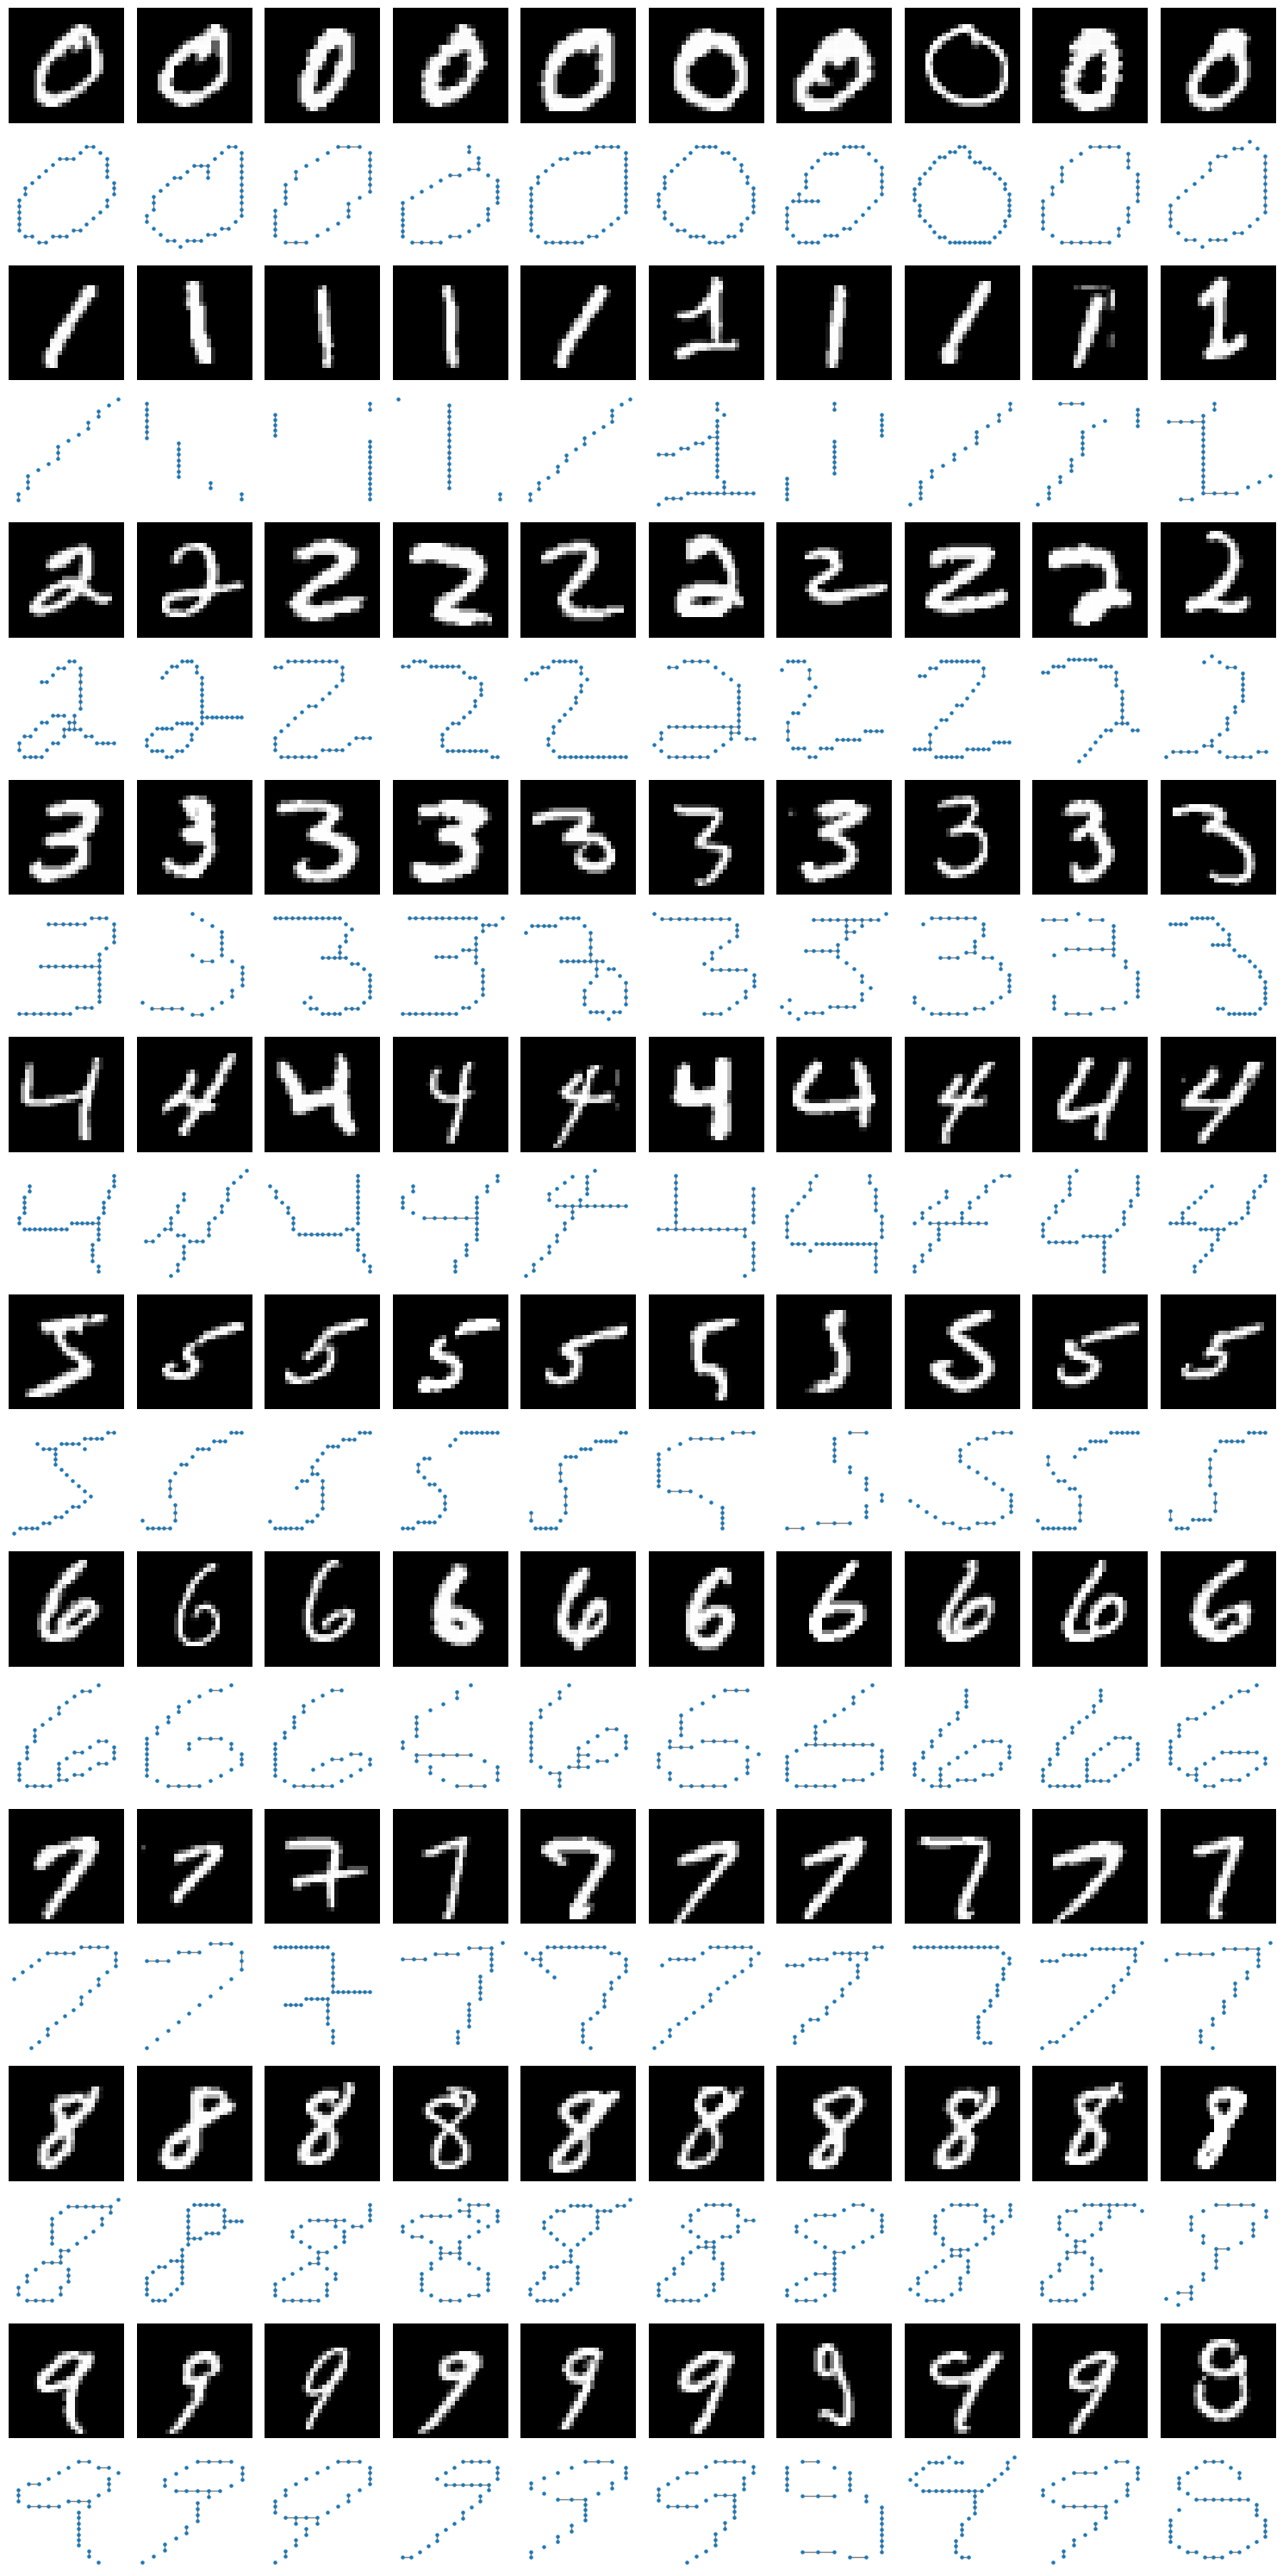

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from skimage.morphology import skeletonize
from tensorflow.keras.datasets import mnist

def preprocess_image(image):
    """Preprocess the image to obtain its skeleton."""
    _, binary = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY)
    skeleton = skeletonize(binary // 255)
    return skeleton

def extract_graph(skeleton):
    """Extract a graph from the skeleton image."""
    G = nx.Graph()
    for y in range(skeleton.shape[0]):
        for x in range(skeleton.shape[1]):
            if skeleton[y, x] == 1:  # Skeleton pixels are 1
                G.add_node((x, -y))  # Flip y-axis for better visualization
                if x > 0 and skeleton[y, x - 1] == 1:
                    G.add_edge((x, -y), (x - 1, -y))
                if y > 0 and skeleton[y - 1, x] == 1:
                    G.add_edge((x, -y), (x, -y + 1))
    return G

def plot_graph(G, ax):
    """Plot the graph on the given axis."""
    pos = {node: node for node in G.nodes()}
    nx.draw(G, pos, ax=ax, node_size=5, edge_color='gray', with_labels=False)

# Load the MNIST dataset
(x_train, y_train), _ = mnist.load_data()

# Create a figure with 20 rows (10 digits, each with image + graph) and 10 columns
fig, axes = plt.subplots(20, 10, figsize=(15, 30))

for i in range(10):
    images = x_train[y_train == i][:10]  # Get first 10 images of digit i
    for j, image in enumerate(images):
        axes[2 * i, j].imshow(image, cmap='gray')
        axes[2 * i, j].axis('off')
        
        skeleton = preprocess_image(image)
        G = extract_graph(skeleton)
        
        plot_graph(G, axes[2 * i + 1, j])
        axes[2 * i + 1, j].axis('off')

plt.tight_layout()
plt.show()